# Geometry Preservation Evaluation

> Goal: verify the generated frame preserves scene geometry and appearance using full-frame alignment and comparison.

This notebook runs the following pipeline:
1. Set `VIDEO_NAME` and `FRAME_NAME` in the config cell.
2. Align generated frame to reference using full-frame feature matches.
3. Report simple consistency metrics and visualize diagnostics.
4. Use object mask only for final visualization overlay (not for scoring).

In [1]:
import json
from pathlib import Path
from typing import Any, Dict, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (14, 6)
np.set_printoptions(precision=4, suppress=True)

In [2]:
PROJECT_ROOT = Path('/my_workspace/4DHHOI')
VIDEO_NAME = 'video_01'
FRAME_NAME = 'frame_00'  # e.g., frame_00, frame_01, ...

# Used only for the final visualization overlay, not for evaluation.
OBJECT_MASK_NAME = 'target_mask.png'

selection_root = PROJECT_ROOT / '4DHSI/Select_Target_Instance/output' / VIDEO_NAME
reference_path = selection_root / '2d/scene_image.png'
object_mask_path = selection_root / '2d' / OBJECT_MASK_NAME

generated_root = PROJECT_ROOT / '4DHSI/Generate_Video/output_gemini' / VIDEO_NAME / 'first_frames'
generated_path = generated_root / f'{FRAME_NAME}.png'
if not generated_path.exists():
    candidates = sorted(generated_root.glob('frame_*.png'))
    if not candidates:
        raise FileNotFoundError(f'No generated frame found under: {generated_root}')
    generated_path = candidates[0]
    print(f'Fallback generated frame: {generated_path.name}')

resized_dir = generated_root.parent / 'first_frames_resized'
resized_path = resized_dir / generated_path.name

report_path = (
    PROJECT_ROOT
    / '4DHSI/Generate_Video/output_gemini'
    / VIDEO_NAME
    / f'geometry_preservation_evaluation_{generated_path.stem}.json'
)

thresholds = {
    'inlier_ratio_min': 0.45,
    'median_reproj_max_px': 3.0,
    'mae_max': 12.0,
    'edge_iou_min': 0.15,
}

for p in [reference_path, object_mask_path, generated_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

print('Video:', VIDEO_NAME)
print('Frame:', generated_path.name)
print('Reference:', reference_path)
print('Object mask (visualization only):', object_mask_path)
print('Resized frame output:', resized_path)
print('Report output:', report_path)

Video: video_01
Frame: frame_00.png
Reference: /my_workspace/4DHHOI/4DHSI/Select_Target_Instance/output/video_01/2d/scene_image.png
Object mask (visualization only): /my_workspace/4DHHOI/4DHSI/Select_Target_Instance/output/video_01/2d/target_mask.png
Resized frame output: /my_workspace/4DHHOI/4DHSI/Generate_Video/output_gemini/video_01/first_frames_resized/frame_00.png
Report output: /my_workspace/4DHHOI/4DHSI/Generate_Video/output_gemini/video_01/geometry_preservation_evaluation_frame_00.json


In [3]:
def read_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f'Failed to read image: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def load_binary_mask(path: Path, shape_hw: Tuple[int, int]) -> np.ndarray:
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(f'Failed to read mask: {path}')
    if mask.shape != shape_hw:
        mask = cv2.resize(mask, (shape_hw[1], shape_hw[0]), interpolation=cv2.INTER_NEAREST)
    return mask > 127


def save_resized_generated_frame(
    reference_path: Path,
    generated_path: Path,
    resized_path: Path,
) -> Path:
    ref_rgb = read_rgb(reference_path)
    gen_rgb = read_rgb(generated_path)
    ref_h, ref_w = ref_rgb.shape[:2]

    if gen_rgb.shape[:2] == (ref_h, ref_w):
        resized_rgb = gen_rgb
    else:
        resized_rgb = cv2.resize(gen_rgb, (ref_w, ref_h), interpolation=cv2.INTER_CUBIC)

    resized_path.parent.mkdir(parents=True, exist_ok=True)
    saved_ok = cv2.imwrite(str(resized_path), cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2BGR))
    if not saved_ok:
        raise IOError(f'Failed to write resized image: {resized_path}')
    return resized_path


def create_feature_backend() -> Tuple[str, Any, int]:
    if hasattr(cv2, 'SIFT_create'):
        return 'SIFT', cv2.SIFT_create(nfeatures=6000), cv2.NORM_L2
    return 'ORB', cv2.ORB_create(nfeatures=6000, fastThreshold=5), cv2.NORM_HAMMING


def estimate_homography_fullframe(
    ref_gray: np.ndarray,
    gen_gray: np.ndarray,
    ratio_test: float = 0.75,
    ransac_thresh_px: float = 4.0,
) -> Dict[str, Any]:
    detector_name, detector, matcher_norm = create_feature_backend()

    kp_ref, desc_ref = detector.detectAndCompute(ref_gray, None)
    kp_gen, desc_gen = detector.detectAndCompute(gen_gray, None)
    if desc_ref is None or desc_gen is None:
        raise RuntimeError('Could not compute full-frame descriptors.')

    matcher = cv2.BFMatcher(matcher_norm)
    raw_matches = matcher.knnMatch(desc_ref, desc_gen, k=2)

    good_matches = []
    for pair in raw_matches:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio_test * n.distance:
            good_matches.append(m)

    if len(good_matches) < 8:
        raise RuntimeError(f'Not enough matches for homography: {len(good_matches)}')

    src_pts = np.float32([kp_gen[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_ref[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    H, inlier_mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh_px)
    if H is None or inlier_mask is None:
        raise RuntimeError('Homography estimation failed.')

    inlier_mask = inlier_mask.ravel().astype(bool)
    n_inliers = int(inlier_mask.sum())
    inlier_ratio = float(n_inliers / len(good_matches))

    proj_pts = cv2.perspectiveTransform(src_pts, H).reshape(-1, 2)
    dst_flat = dst_pts.reshape(-1, 2)
    reproj_err = np.linalg.norm(proj_pts - dst_flat, axis=1)
    inlier_err = reproj_err[inlier_mask]

    if inlier_err.size > 0:
        med_err = float(np.median(inlier_err))
        mean_err = float(np.mean(inlier_err))
    else:
        med_err = float('nan')
        mean_err = float('nan')

    inlier_matches = [m for i, m in enumerate(good_matches) if inlier_mask[i]]
    if len(inlier_matches) > 200:
        rng = np.random.default_rng(0)
        selected = rng.choice(len(inlier_matches), size=200, replace=False)
        draw_matches = [inlier_matches[i] for i in selected]
    else:
        draw_matches = inlier_matches

    match_vis = cv2.drawMatches(
        ref_gray, kp_ref, gen_gray, kp_gen, draw_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    return {
        'detector': detector_name,
        'H': H,
        'match_vis': match_vis,
        'n_keypoints_reference': int(len(kp_ref)),
        'n_keypoints_generated': int(len(kp_gen)),
        'n_good_matches': int(len(good_matches)),
        'n_inliers': n_inliers,
        'inlier_ratio': inlier_ratio,
        'median_reprojection_error_px': med_err,
        'mean_reprojection_error_px': mean_err,
    }


def compute_fullframe_metrics(ref_rgb: np.ndarray, warped_rgb: np.ndarray) -> Dict[str, Any]:
    ref_f = ref_rgb.astype(np.float32)
    wrp_f = warped_rgb.astype(np.float32)
    abs_diff = np.abs(ref_f - wrp_f)
    mae = float(abs_diff.mean())

    mse = float(np.mean((ref_f - wrp_f) ** 2))
    if mse <= 1e-12:
        psnr = float('inf')
    else:
        psnr = float(20.0 * np.log10(255.0) - 10.0 * np.log10(mse))

    ref_gray = cv2.cvtColor(ref_rgb, cv2.COLOR_RGB2GRAY)
    wrp_gray = cv2.cvtColor(warped_rgb, cv2.COLOR_RGB2GRAY)
    edges_ref = cv2.Canny(ref_gray, 100, 200) > 0
    edges_wrp = cv2.Canny(wrp_gray, 100, 200) > 0

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    ref_tol = cv2.dilate((edges_ref.astype(np.uint8) * 255), kernel) > 0
    wrp_tol = cv2.dilate((edges_wrp.astype(np.uint8) * 255), kernel) > 0

    inter = int(np.logical_and(ref_tol, wrp_tol).sum())
    union = int(np.logical_or(ref_tol, wrp_tol).sum())
    edge_iou = float(inter / union) if union > 0 else 0.0

    diff_gray = cv2.cvtColor(cv2.absdiff(ref_rgb, warped_rgb), cv2.COLOR_RGB2GRAY)

    return {
        'fullframe_mae_rgb': mae,
        'fullframe_psnr_db': psnr,
        'fullframe_edge_iou': edge_iou,
        'diff_gray': diff_gray,
    }


def build_verdict(metrics: Dict[str, float], checks_cfg: Dict[str, float]) -> Dict[str, Any]:
    checks = {
        'inlier_ratio_ok': metrics['inlier_ratio'] >= checks_cfg['inlier_ratio_min'],
        'median_reprojection_ok': metrics['median_reprojection_error_px'] <= checks_cfg['median_reproj_max_px'],
        'mae_ok': metrics['fullframe_mae_rgb'] <= checks_cfg['mae_max'],
        'edge_iou_ok': metrics['fullframe_edge_iou'] >= checks_cfg['edge_iou_min'],
    }
    pass_fraction = float(sum(checks.values()) / len(checks))

    if pass_fraction >= 0.75:
        verdict = 'Strong full-frame preservation'
    elif pass_fraction >= 0.5:
        verdict = 'Moderate preservation; inspect diagnostics'
    else:
        verdict = 'Weak preservation; likely scene drift'

    return {'checks': checks, 'pass_fraction': pass_fraction, 'verdict': verdict}


def run_geometry_eval(
    reference_path: Path,
    generated_path: Path,
    object_mask_path: Path,
    thresholds: Dict[str, float],
) -> Dict[str, Any]:
    ref_rgb = read_rgb(reference_path)
    gen_rgb = read_rgb(generated_path)

    ref_h, ref_w = ref_rgb.shape[:2]
    if gen_rgb.shape[:2] != (ref_h, ref_w):
        raise ValueError(
            f'Generated frame shape {gen_rgb.shape[:2]} does not match reference shape {(ref_h, ref_w)}. '
            'Pass a pre-resized frame to run_geometry_eval.'
        )

    object_mask = load_binary_mask(object_mask_path, (ref_h, ref_w))

    ref_gray = cv2.cvtColor(ref_rgb, cv2.COLOR_RGB2GRAY)
    gen_gray = cv2.cvtColor(gen_rgb, cv2.COLOR_RGB2GRAY)

    h_info = estimate_homography_fullframe(ref_gray, gen_gray)
    warped_gen = cv2.warpPerspective(gen_rgb, h_info['H'], (ref_w, ref_h), flags=cv2.INTER_CUBIC)

    f_info = compute_fullframe_metrics(ref_rgb, warped_gen)

    summary = {
        'video_name': VIDEO_NAME,
        'frame_name': generated_path.stem,
        'reference_path': str(reference_path),
        'generated_path': str(generated_path),
        'object_mask_path_visualization_only': str(object_mask_path),
        'detector': h_info['detector'],
        'n_keypoints_reference': h_info['n_keypoints_reference'],
        'n_keypoints_generated': h_info['n_keypoints_generated'],
        'n_good_matches': h_info['n_good_matches'],
        'n_inliers': h_info['n_inliers'],
        'inlier_ratio': h_info['inlier_ratio'],
        'median_reprojection_error_px': h_info['median_reprojection_error_px'],
        'mean_reprojection_error_px': h_info['mean_reprojection_error_px'],
        'fullframe_mae_rgb': f_info['fullframe_mae_rgb'],
        'fullframe_psnr_db': f_info['fullframe_psnr_db'],
        'fullframe_edge_iou': f_info['fullframe_edge_iou'],
    }

    verdict = build_verdict(summary, thresholds)
    summary.update(verdict)

    artifacts = {
        'ref_rgb': ref_rgb,
        'gen_rgb': gen_rgb,
        'warped_gen': warped_gen,
        'match_vis': h_info['match_vis'],
        'diff_gray': f_info['diff_gray'],
        'object_mask': object_mask,
    }
    return {'summary': summary, 'artifacts': artifacts}

In [4]:
resized_eval_path = save_resized_generated_frame(
    reference_path=reference_path,
    generated_path=generated_path,
    resized_path=resized_path,
)

result = run_geometry_eval(
    reference_path=reference_path,
    generated_path=resized_eval_path,
    object_mask_path=object_mask_path,
    thresholds=thresholds,
)

summary = result['summary']
artifacts = result['artifacts']

summary['source_generated_path'] = str(generated_path)
summary['resized_generated_path'] = str(resized_eval_path)

print(json.dumps(summary, indent=2))

report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print('Wrote resized frame:', resized_eval_path)
print('Wrote report:', report_path)

{
  "video_name": "video_01",
  "frame_name": "frame_00",
  "reference_path": "/my_workspace/4DHHOI/4DHSI/Select_Target_Instance/output/video_01/2d/scene_image.png",
  "generated_path": "/my_workspace/4DHHOI/4DHSI/Generate_Video/output_gemini/video_01/first_frames_resized/frame_00.png",
  "object_mask_path_visualization_only": "/my_workspace/4DHHOI/4DHSI/Select_Target_Instance/output/video_01/2d/target_mask.png",
  "detector": "SIFT",
  "n_keypoints_reference": 264,
  "n_keypoints_generated": 421,
  "n_good_matches": 95,
  "n_inliers": 67,
  "inlier_ratio": 0.7052631578947368,
  "median_reprojection_error_px": 0.7844769954681396,
  "mean_reprojection_error_px": 0.986036479473114,
  "fullframe_mae_rgb": 4.291685581207275,
  "fullframe_psnr_db": 25.473006997446436,
  "fullframe_edge_iou": 0.5605828625732537,
  "checks": {
    "inlier_ratio_ok": true,
    "median_reprojection_ok": true,
    "mae_ok": true,
    "edge_iou_ok": true
  },
  "pass_fraction": 1.0,
  "verdict": "Strong full-fram

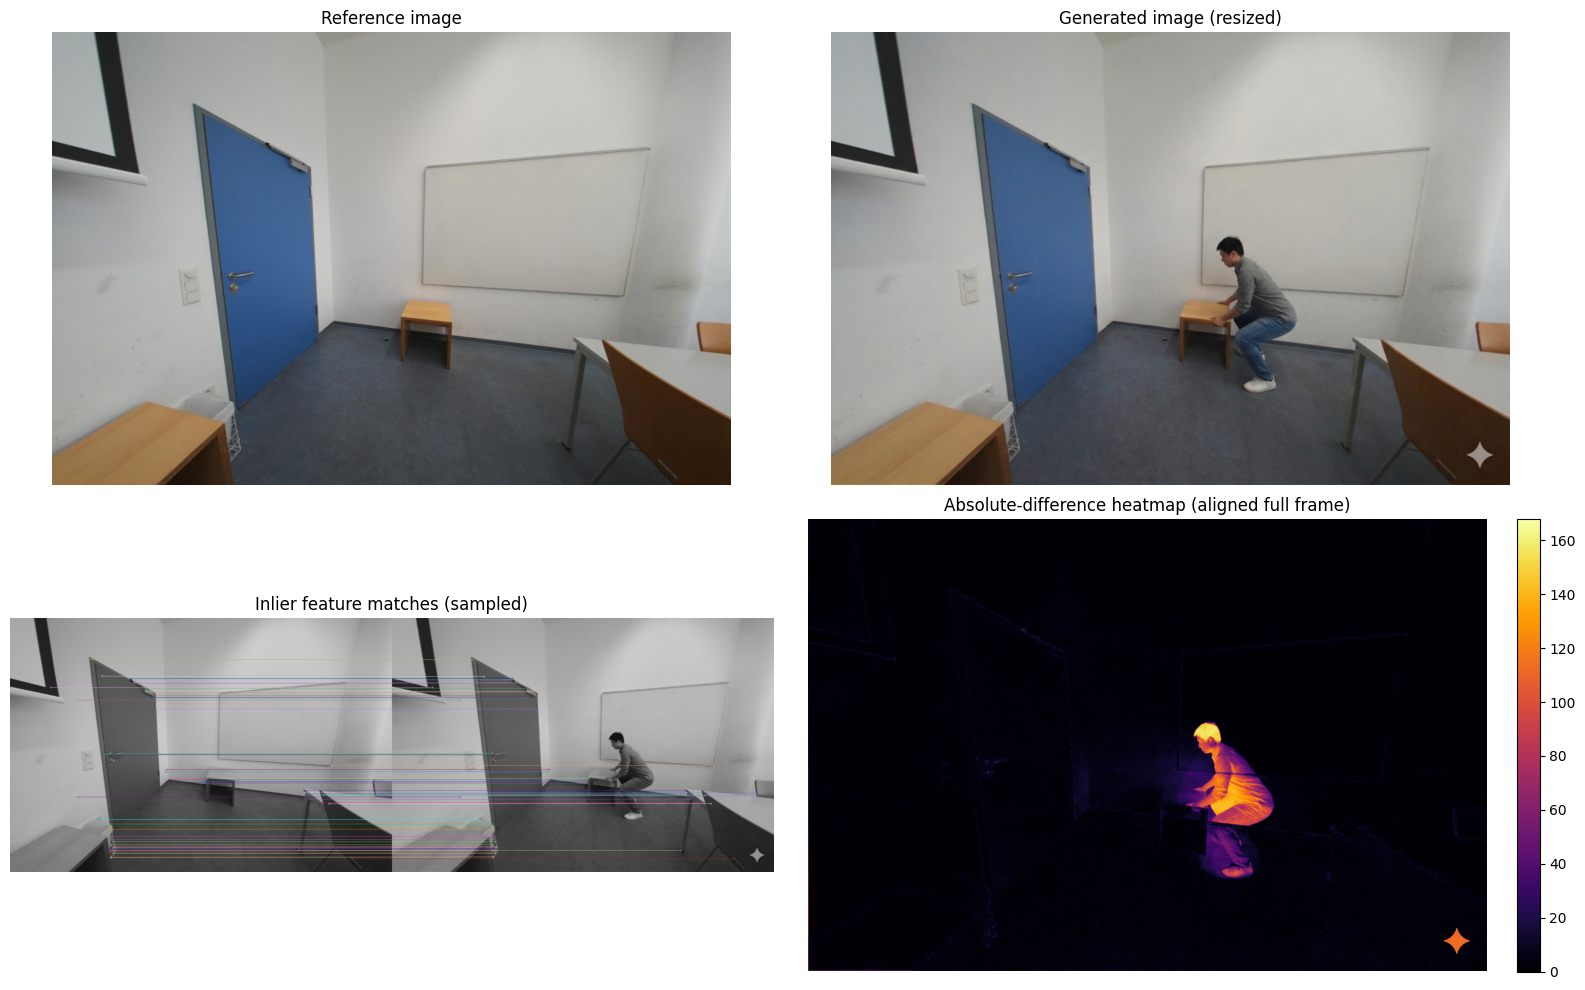

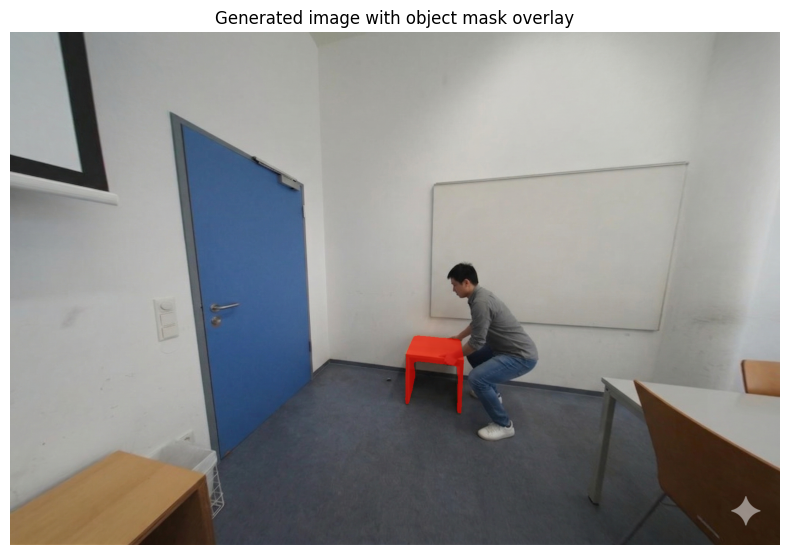

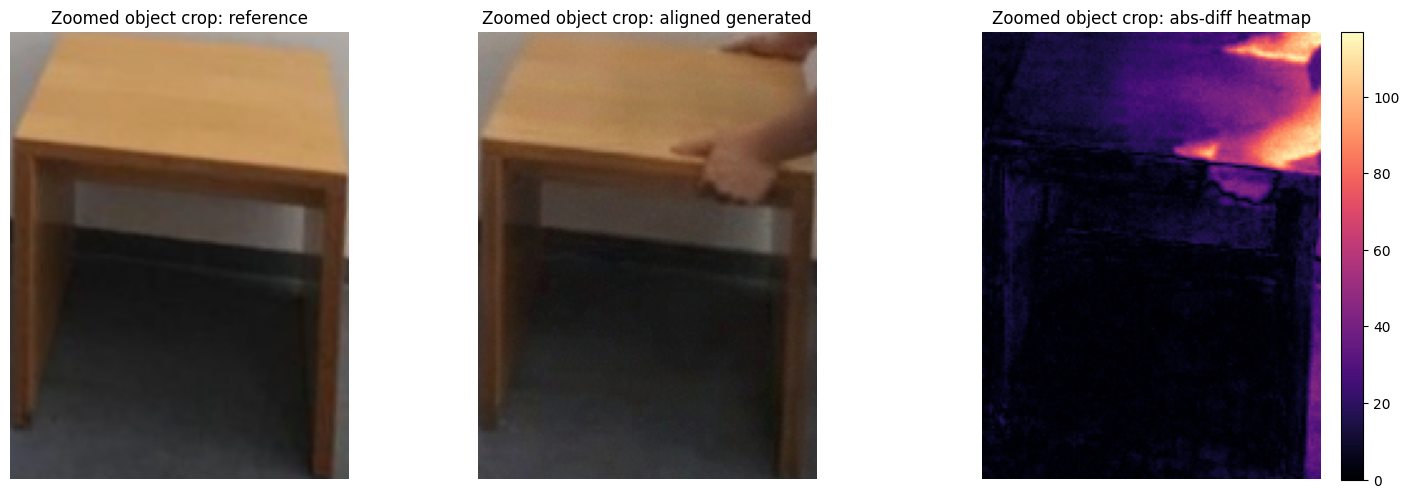

In [5]:
ref_rgb = artifacts['ref_rgb']
gen_rgb = artifacts['gen_rgb']
warped_gen = artifacts['warped_gen']
match_vis = artifacts['match_vis']
diff_gray = artifacts['diff_gray']
object_mask = artifacts['object_mask']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].imshow(ref_rgb)
axes[0, 0].set_title('Reference image')
axes[0, 1].imshow(gen_rgb)
axes[0, 1].set_title('Generated image (resized)')
axes[1, 0].imshow(match_vis)
axes[1, 0].set_title('Inlier feature matches (sampled)')
im = axes[1, 1].imshow(diff_gray, cmap='inferno')
axes[1, 1].set_title('Absolute-difference heatmap (aligned full frame)')
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()

overlay_gen = gen_rgb.copy()
alpha = 0.55
overlay_gen[object_mask] = (
    (1.0 - alpha) * overlay_gen[object_mask] + alpha * np.array([255, 0, 0], dtype=np.float32)
).astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.imshow(overlay_gen)
plt.title('Generated image with object mask overlay')
plt.axis('off')
plt.tight_layout()

# Zoomed object-region diagnostic (from mask bounding box).
if np.any(object_mask):
    ys, xs = np.where(object_mask)
    y0, y1 = int(ys.min()), int(ys.max())
    x0, x1 = int(xs.min()), int(xs.max())

    obj_ref = ref_rgb[y0:y1+1, x0:x1+1]
    obj_warp = warped_gen[y0:y1+1, x0:x1+1]
    obj_diff = cv2.cvtColor(cv2.absdiff(obj_ref, obj_warp), cv2.COLOR_RGB2GRAY)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(obj_ref)
    axes[0].set_title('Zoomed object crop: reference')
    axes[1].imshow(obj_warp)
    axes[1].set_title('Zoomed object crop: aligned generated')
    im = axes[2].imshow(obj_diff, cmap='magma')
    axes[2].set_title('Zoomed object crop: abs-diff heatmap')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
else:
    print('Object mask is empty; skipping zoomed crop diagnostic.')